# Unit12 程序最適化 | scipy.optimize 套件應用

本 Notebook 介紹 `scipy.optimize` 套件的各類最適化工具，並透過化工問題示範其應用。

## 學習目標
- 掌握 `minimize_scalar()` 求解單變數有界最適化問題
- 掌握 `minimize()` 求解無限制及有限制條件之多變數非線性最適化問題
- 掌握 `linprog()` 求解線性規劃問題
- 掌握 `milp()` 求解混合整數線性規劃問題
- 理解全域最適化工具：`differential_evolution()`、`dual_annealing()` 等

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit12_Optimization'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit12'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit12
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Optimization
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Optimization\figs


---
### 1. 載入套件

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# scipy.optimize 最適化函式
from scipy.optimize import (
    minimize_scalar,          # 單變數最適化
    minimize,                 # 多變數最適化（無/有限制條件）
    linprog,                  # 線性規劃
    milp,                     # 混合整數線性規劃
    differential_evolution,   # 全域最適化：差分進化
    dual_annealing,           # 全域最適化：雙退火
    basinhopping,             # 全域最適化：盆地跳躍
    shgo,                     # 全域最適化：SHGO
    Bounds,                   # 變數邊界物件
    LinearConstraint,         # 線性限制條件物件
    NonlinearConstraint,      # 非線性限制條件物件
)

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

import scipy
import matplotlib
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. scipy.optimize 模組架構總覽

| 函式 | 用途 |
|------|------|
| `minimize_scalar()` | 單變數有界最適化 |
| `minimize()` | 多變數最適化（無/有限制條件）|
| `linprog()` | 線性規劃 |
| `milp()` | 混合整數線性規劃 |
| `differential_evolution()` | 全域最適化（差分演化）|
| `dual_annealing()` | 全域最適化（雙退火）|
| `basinhopping()` | 全域最適化（盆地跳躍）|
| `shgo()` | 全域最適化（SHGO）|

In [3]:
# ============================================================
# 示範 OptimizeResult 物件結構
# ============================================================

# 求解一個簡單的二次函數：min x1^2 + (x2-1)^2
result = minimize(lambda x: x[0]**2 + (x[1]-1)**2, x0=[2.0, 3.0], method='BFGS')

print("=" * 50)
print("OptimizeResult 物件屬性示範")
print("=" * 50)
print(f"  result.x        (最適解)       : {result.x}")
print(f"  result.fun      (最小函數值)   : {result.fun:.6e}")
print(f"  result.success  (是否收斂)     : {result.success}")
print(f"  result.message  (終止訊息)     : {result.message}")
print(f"  result.nit      (迭代次數)     : {result.nit}")
print(f"  result.nfev     (函數評估次數) : {result.nfev}")
print(f"  result.njev     (梯度評估次數) : {result.njev}")

OptimizeResult 物件屬性示範
  result.x        (最適解)       : [-5.85244586e-09  9.99999994e-01]
  result.fun      (最小函數值)   : 6.850225e-17
  result.success  (是否收斂)     : True
  result.message  (終止訊息)     : Optimization terminated successfully.
  result.nit      (迭代次數)     : 2
  result.nfev     (函數評估次數) : 9
  result.njev     (梯度評估次數) : 3


---
### 3. 單變數最適化 — `minimize_scalar()`

適用情境：目標函數只有 **一個** 決策變數，例如尋找最適反應溫度、最適濃度等。

| 方法 | 關鍵參數 | 說明 |
|------|----------|------|
| `'brent'` | `bracket=(a,b)` | Brent 法，無需提供嚴格邊界，收斂速度快（預設） |
| `'bounded'` | `bounds=(a,b)` | 有界 Brent 法，保證在 $[a,b]$ 內搜尋 |
| `'golden'` | `bracket=(a,b)` | 黃金分割法，較穩健但收斂較慢 |

**示範目標函數**：尋找 $f(x) = x^3 + x^2 - 2x - 5$ 在 $[0,2]$ 的最小值

3. minimize_scalar — 三種方法比較
  Method             x*        f(x*)   nfev
  ------------------------------------------
  bounded      0.548584    -5.631130      9
  brent        0.548584    -5.631130     18
  golden       0.548584    -5.631130     45


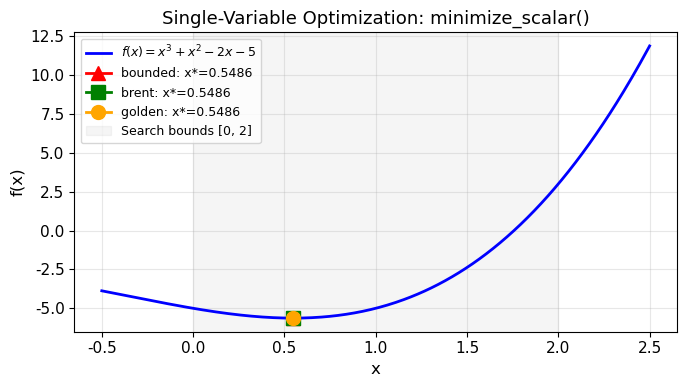

  [Saved] d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Optimization\figs\unit12_minimize_scalar.png


In [5]:
# ============================================================
# 3. minimize_scalar() — 三種方法比較
# ============================================================

def f_scalar(x):
    """目標函數 f(x) = x^3 + x^2 - 2x - 5"""
    return x**3 + x**2 - 2*x - 5

SEARCH_BOUNDS = (0, 2)

# --- 三種方法求解 ---
res_bounded = minimize_scalar(f_scalar, bounds=SEARCH_BOUNDS, method='bounded')
res_brent   = minimize_scalar(f_scalar, bracket=(0.5, 1.5),   method='brent')
res_golden  = minimize_scalar(f_scalar, bracket=(0.5, 1.5),   method='golden')

print("3. minimize_scalar — 三種方法比較")
print(f"  {'Method':<10} {'x*':>10} {'f(x*)':>12} {'nfev':>6}")
print(f"  {'-'*42}")
for label, res in [('bounded', res_bounded), ('brent', res_brent), ('golden', res_golden)]:
    print(f"  {label:<10} {res.x:>10.6f} {res.fun:>12.6f} {res.nfev:>6d}")

# --- 繪圖 ---
fig, ax = plt.subplots(figsize=(7, 4))

x_arr = np.linspace(-0.5, 2.5, 400)
ax.plot(x_arr, f_scalar(x_arr), 'b-', lw=2, label='$f(x) = x^3+x^2-2x-5$')

colors = {'bounded': 'red', 'brent': 'green', 'golden': 'orange'}
markers = {'bounded': '^', 'brent': 's', 'golden': 'o'}
for label, res in [('bounded', res_bounded), ('brent', res_brent), ('golden', res_golden)]:
    ax.plot(res.x, res.fun, marker=markers[label], markersize=10,
            color=colors[label], label=f'{label}: x*={res.x:.4f}')

ax.axvspan(SEARCH_BOUNDS[0], SEARCH_BOUNDS[1], alpha=0.08, color='gray', label='Search bounds [0, 2]')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Single-Variable Optimization: minimize_scalar()')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "unit12_minimize_scalar.png"
fig.savefig(fig_path, dpi=120)
plt.show()
print(f"  [Saved] {fig_path}")

---
### 4. 無限制條件多變數最適化 — `minimize()`

`minimize()` 是 scipy.optimize 最通用的介面，支援多種數值方法。

```python
scipy.optimize.minimize(fun, x0, method=None, jac=None, options=None)
```

| 方法 | 需要梯度 | 特性 |
|------|----------|------|
| `'BFGS'` | 可選（自動差分） | 擬牛頓法，快速收斂，工業常用 |
| `'Nelder-Mead'` | 否 | 單純形法，不需要導數，適合雜訊目標函數 |
| `'L-BFGS-B'` | 可選 | 低記憶體 BFGS，適合大規模問題 |
| `'CG'` | 可選 | 共軛梯度法 |

**示範目標函數**：Rosenbrock 函數 $f(x_1,x_2) = (1-x_1)^2 + 100(x_2-x_1^2)^2$

- 全局最小值在 $(x_1, x_2) = (1, 1)$ ，$f^* = 0$

4. Rosenbrock 函數最適化 (初始點 x0 = [-1.0, 0.5])
  Method              x1*      x2*           f*    nit   nfev
  --------------------------------------------------------
  BFGS+grad       1.00000  1.00000     2.18e-22     33     42
  Nelder-Mead     1.00000  1.00000     4.11e-18    123    233


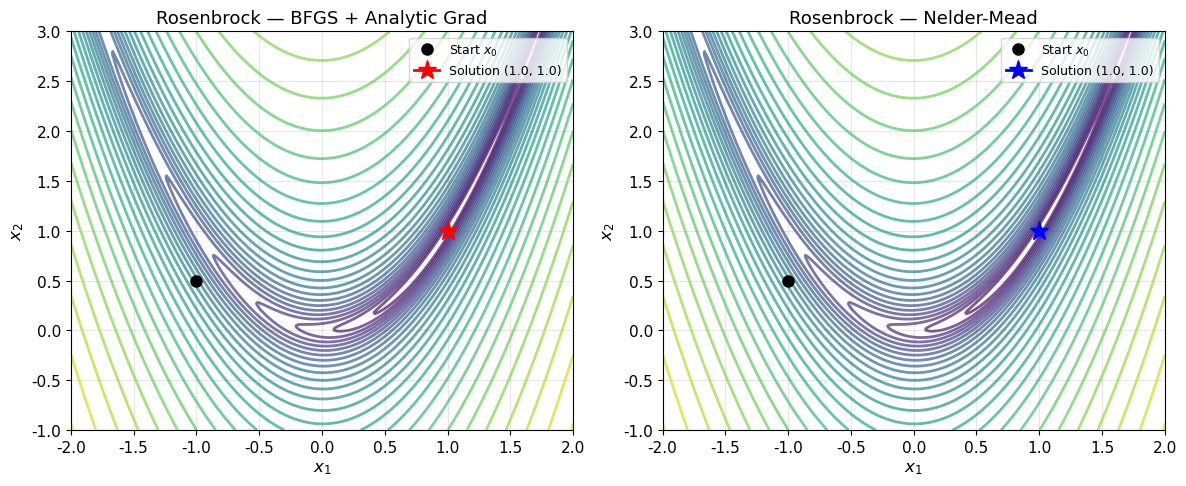

  [Saved] d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Optimization\figs\unit12_rosenbrock.png


In [6]:
# ============================================================
# 4. minimize() — Rosenbrock 函數，BFGS vs Nelder-Mead
# ============================================================

def rosenbrock(x):
    """Rosenbrock: f(x) = (1-x0)^2 + 100*(x1-x0^2)^2"""
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def rosenbrock_grad(x):
    """解析梯度"""
    df_dx0 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    df_dx1 =  200*(x[1] - x[0]**2)
    return np.array([df_dx0, df_dx1])

x0_init = np.array([-1.0, 0.5])

# BFGS with analytic gradient
res_bfgs = minimize(rosenbrock, x0_init, method='BFGS', jac=rosenbrock_grad,
                    options={'gtol': 1e-8})
# Nelder-Mead without gradient
res_nm   = minimize(rosenbrock, x0_init, method='Nelder-Mead',
                    options={'xatol': 1e-8, 'fatol': 1e-10, 'maxiter': 10000})

print("4. Rosenbrock 函數最適化 (初始點 x0 = [-1.0, 0.5])")
print(f"  {'Method':<14} {'x1*':>8} {'x2*':>8} {'f*':>12} {'nit':>6} {'nfev':>6}")
print(f"  {'-'*56}")
for label, res in [('BFGS+grad', res_bfgs), ('Nelder-Mead', res_nm)]:
    print(f"  {label:<14} {res.x[0]:>8.5f} {res.x[1]:>8.5f} {res.fun:>12.2e}"
          f" {res.nit:>6d} {res.nfev:>6d}")

# --- 等高線圖 ---
x1_range = np.linspace(-2, 2, 300)
x2_range = np.linspace(-1, 3, 300)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = (1 - X1)**2 + 100*(X2 - X1**2)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, res, color in zip(axes,
                                  ['BFGS + Analytic Grad', 'Nelder-Mead'],
                                  [res_bfgs, res_nm],
                                  ['red', 'blue']):
    ax.contour(X1, X2, np.log1p(Z), levels=30, cmap='viridis', alpha=0.7)
    ax.plot(*x0_init, 'ko', markersize=8, label='Start $x_0$')
    ax.plot(*res.x, marker='*', markersize=14, color=color, label=f'Solution {tuple(res.x.round(4))}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'Rosenbrock — {label}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "unit12_rosenbrock.png"
fig.savefig(fig_path, dpi=120)
plt.show()
print(f"  [Saved] {fig_path}")

---
### 5. 有限制條件非線性最適化 (NLP) — `minimize()` SLSQP

適用情境：目標函數含有等式/不等式限制條件與變數邊界。

```python
# 方式 A：constraints=dict (舊式，相容性佳)
constraints = [
    {'type': 'ineq', 'fun': lambda x: g(x)},   # g(x) >= 0
    {'type': 'eq',   'fun': lambda x: h(x)},   # h(x) == 0
]

# 方式 B：Bounds + NonlinearConstraint (新式，SciPy >= 1.1)
bounds       = Bounds([lb1, lb2], [ub1, ub2])
nlc          = NonlinearConstraint(fun, lb, ub)  # lb <= fun(x) <= ub
```

> ⚠️ **不等式符號慣例**：SciPy `'ineq'` 型別定義為 $g(x) \geq 0$ （函數值不得為負），須確保不等式限制條件以 $g(x) \geq 0$ 形式撰寫。

**示範題目（化工程序最適化）**：

$$
\min_{x_1, x_2} \; f = (x_1 - 3)^2 + (x_2 - 2)^2
$$

$$
\text{s.t.} \quad g_1: x_1 + x_2 \leq 4, \quad g_2: x_1^2 + x_2^2 \leq 9, \quad x_1, x_2 \geq 0
$$

5. NLP 有限制條件最適化 (SLSQP)
  Method                x1*      x2*         f* OK?
  --------------------------------------------------
  dict constraints  2.50000  1.50000   0.500000  ✓
  Bounds+NLC        2.50000  1.50000   0.500000  ✓


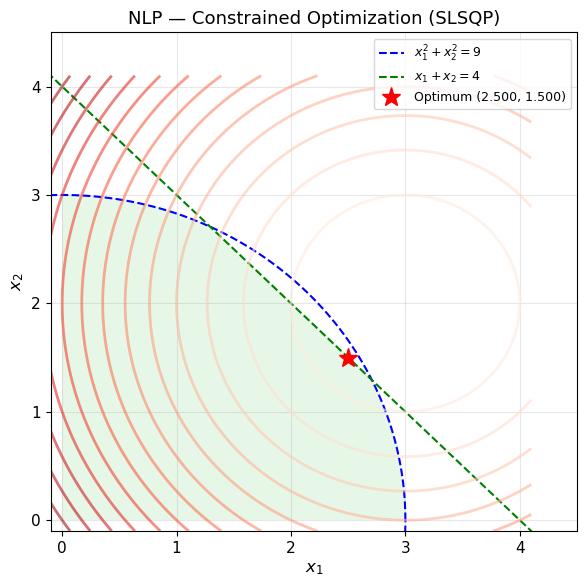

  [Saved] d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Optimization\figs\unit12_slsqp_nlp.png


In [7]:
# ============================================================
# 5. minimize() SLSQP — 有限制條件 NLP
# ============================================================

def obj_nlp(x):
    return (x[0] - 3)**2 + (x[1] - 2)**2

x0_nlp = [1.0, 1.0]

# --- 方式 A：constraints=dict ---
constraints_A = [
    {'type': 'ineq', 'fun': lambda x:  4 - x[0] - x[1]},   # x1+x2 <= 4  → 4-x1-x2 >= 0
    {'type': 'ineq', 'fun': lambda x:  9 - x[0]**2 - x[1]**2},  # x1^2+x2^2 <= 9
]
bounds_A = [(0, None), (0, None)]

res_A = minimize(obj_nlp, x0_nlp, method='SLSQP',
                 constraints=constraints_A, bounds=bounds_A)

# --- 方式 B：Bounds + NonlinearConstraint ---
bounds_B = Bounds([0, 0], [np.inf, np.inf])

def g_combined(x):
    """返回 [4-x1-x2, 9-x1^2-x2^2]"""
    return [4 - x[0] - x[1], 9 - x[0]**2 - x[1]**2]

nlc_B = NonlinearConstraint(g_combined, lb=0, ub=np.inf)

res_B = minimize(obj_nlp, x0_nlp, method='SLSQP',
                 constraints=[nlc_B], bounds=bounds_B)

# --- 輸出結果 ---
print("5. NLP 有限制條件最適化 (SLSQP)")
print(f"  {'Method':<16} {'x1*':>8} {'x2*':>8} {'f*':>10} {'OK?'}")
print(f"  {'-'*50}")
for label, res in [('dict constraints', res_A), ('Bounds+NLC', res_B)]:
    ok = "✓" if res.success else "✗"
    print(f"  {label:<16} {res.x[0]:>8.5f} {res.x[1]:>8.5f} {res.fun:>10.6f}  {ok}")

# --- 可行域視覺化 ---
fig, ax = plt.subplots(figsize=(6, 6))

theta = np.linspace(0, 2*np.pi, 300)
# 繪製 x1^2 + x2^2 = 9 圓
ax.plot(3*np.cos(theta), 3*np.sin(theta), 'b--', lw=1.5, label='$x_1^2+x_2^2=9$')
# 繪製 x1 + x2 = 4 線
x_line = np.linspace(-0.2, 4.2, 100)
ax.plot(x_line, 4 - x_line, 'g--', lw=1.5, label='$x_1+x_2=4$')
# 可行域填色（數值近似）
x1g = np.linspace(-0.1, 4.1, 300)
x2g = np.linspace(-0.1, 4.1, 300)
X1g, X2g = np.meshgrid(x1g, x2g)
feasible = (X1g >= 0) & (X2g >= 0) & (X1g+X2g <= 4) & (X1g**2+X2g**2 <= 9)
ax.contourf(X1g, X2g, feasible.astype(float), levels=[0.5, 1.5], colors=['#d0f0d0'], alpha=0.5)
# 繪製等高線
Z_obj = (X1g - 3)**2 + (X2g - 2)**2
ax.contour(X1g, X2g, Z_obj, levels=15, cmap='Reds', alpha=0.6)
# 繪製最優點
ax.plot(res_A.x[0], res_A.x[1], 'r*', markersize=14, label=f'Optimum ({res_A.x[0]:.3f}, {res_A.x[1]:.3f})')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('NLP — Constrained Optimization (SLSQP)')
ax.legend(fontsize=9)
ax.set_xlim(-0.1, 4.5)
ax.set_ylim(-0.1, 4.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "unit12_slsqp_nlp.png"
fig.savefig(fig_path, dpi=120)
plt.show()
print(f"  [Saved] {fig_path}")

---
### 6. 線性規劃 — `linprog()`

```python
scipy.optimize.linprog(c, A_ub=None, b_ub=None, A_eq=None, b_eq=None,
                        bounds=None, method='highs')
```

`linprog()` **只能求最小化**，目標函數與限制條件均須為線性。

| 參數 | 說明 |
|------|------|
| `c` | 目標函數係數向量（最小化 $\mathbf{c}^T\mathbf{x}$ ） |
| `A_ub`, `b_ub` | 不等式限制 $A_{ub}\mathbf{x} \leq \mathbf{b}_{ub}$ |
| `A_eq`, `b_eq` | 等式限制 $A_{eq}\mathbf{x} = \mathbf{b}_{eq}$ |
| `bounds` | 各變數的上下限 `[(lb1,ub1), ...]` |

> **最大化**：將目標函數乘以 $-1$ 轉換為最小化問題

**示範題目**：生產排程優化

$$
\max \; 5x_1 + 4x_2 + 3x_3
$$

$$
\text{s.t.} \quad 6x_1+4x_2+2x_3 \leq 240, \quad 3x_1+2x_2+5x_3 \leq 270, \quad 5x_1+6x_2+5x_3 \leq 420, \quad x_i \geq 0
$$

In [8]:
# ============================================================
# 6. linprog() — 三產品生產排程最大化
# ============================================================

# 最大化 5x1+4x2+3x3  →  最小化 -5x1-4x2-3x3
c_lp = np.array([-5, -4, -3], dtype=float)

# 不等式限制 A_ub @ x <= b_ub
A_ub = np.array([
    [6, 4, 2],   # 資源 1
    [3, 2, 5],   # 資源 2
    [5, 6, 5],   # 資源 3
], dtype=float)
b_ub = np.array([240, 270, 420], dtype=float)

# 變數下限 0，無上限
bounds_lp = [(0, None)] * 3

res_lp = linprog(c_lp, A_ub=A_ub, b_ub=b_ub, bounds=bounds_lp, method='highs')

print("6. 線性規劃 linprog() — 生產排程")
if res_lp.success:
    x_lp = res_lp.x
    max_profit = -res_lp.fun
    print(f"  x1={x_lp[0]:.4f}, x2={x_lp[1]:.4f}, x3={x_lp[2]:.4f}")
    print(f"  最大利潤 = {max_profit:.4f}")
    print(f"  (linprog 回傳 fun = {res_lp.fun:.4f}，乘以-1 得最大值)")
    # 限制條件餘量
    print("\n  資源使用情況：")
    usages = A_ub @ x_lp
    labels = ['資源 1', '資源 2', '資源 3']
    for lab, used, cap in zip(labels, usages, b_ub):
        print(f"    {lab}: {used:.2f} / {cap:.0f}  (剩餘 {cap-used:.2f})")
else:
    print(f"  求解失敗：{res_lp.message}")

6. 線性規劃 linprog() — 生產排程
  x1=3.7500, x2=35.6250, x3=37.5000
  最大利潤 = 273.7500
  (linprog 回傳 fun = -273.7500，乘以-1 得最大值)

  資源使用情況：
    資源 1: 240.00 / 240  (剩餘 0.00)
    資源 2: 270.00 / 270  (剩餘 0.00)
    資源 3: 420.00 / 420  (剩餘 0.00)


---
### 7. 混合整數線性規劃 — `milp()`

`milp()` 是 SciPy 1.8+ 提供的 MILP 求解器 (HiGHS 後端)，支援整數變數：

```python
from scipy.optimize import milp, LinearConstraint, Bounds

result = milp(c,
              constraints=LinearConstraint(A, lb, ub),
              integrality=integrality,   # 0=連續, 1=整數
              bounds=Bounds(lb_x, ub_x))
```

**示範題目（二元整數規劃 BIP）**：

投資組合選擇問題， $x_i \in \{0,1\}$ ，選擇投資項目以最大化報酬，受總預算限制：

$$
\max \; 5x_1 + 4x_2 + 6x_3 + 3x_4
$$

$$
\text{s.t.} \quad 4x_1 + 5x_2 + 3x_3 + 7x_4 \leq 14, \quad x_i \in \{0,1\}
$$

In [9]:
# ============================================================
# 7. milp() — 二元整數規劃 (BIP)
# ============================================================

# 最大化 5x1+4x2+6x3+3x4  →  最小化 c=-[5,4,6,3]
c_milp = np.array([-5, -4, -6, -3], dtype=float)

# 限制條件：4x1+5x2+3x3+7x4 <= 14 (用 LinearConstraint lb <= Ax <= ub)
A_milp = np.array([[4, 5, 3, 7]], dtype=float)
lc = LinearConstraint(A_milp, lb=-np.inf, ub=14.0)

# 變數邊界：0 <= xi <= 1
bounds_milp = Bounds(lb=np.zeros(4), ub=np.ones(4))

# integrality: 1 = 整數變數
integrality = np.ones(4)

res_milp = milp(c_milp, constraints=lc, integrality=integrality, bounds=bounds_milp)

print("7. 混合整數線性規劃 milp() — 投資組合 BIP")
if res_milp.status == 0:
    x_milp = res_milp.x.astype(int)
    max_return = -res_milp.fun
    print(f"  最優選擇 x = {x_milp}  (1=投資, 0=不投資)")
    print(f"  最大報酬  = {max_return:.0f}")
    cost_used  = A_milp @ res_milp.x
    print(f"  預算使用  = {cost_used[0]:.0f} / 14")
    selected = [f"x{i+1}" for i, v in enumerate(x_milp) if v == 1]
    print(f"  選中項目  = {', '.join(selected)}")
else:
    print(f"  求解失敗：{res_milp.message}")

7. 混合整數線性規劃 milp() — 投資組合 BIP
  最優選擇 x = [1 1 1 0]  (1=投資, 0=不投資)
  最大報酬  = 15
  預算使用  = 12 / 14
  選中項目  = x1, x2, x3


---
### 8. 全域最適化策略

對於具有**多個局部最小值**的非凸目標函數，局部搜尋法（BFGS、Nelder-Mead）可能陷入局部最佳解，需使用全域搜尋演算法。

| 函數 | 演算法 | 特性 |
|------|--------|------|
| `differential_evolution()` | 差分演化（DE） | 啟發式，需要搜尋範圍，適合黑箱問題 |
| `dual_annealing()` | 對偶模擬退火 | 結合 SA + 局部優化，全域性強 |
| `basinhopping()` | 盆地躍遷法 | 局部優化 + 隨機擾動，需要初始點 |
| `shgo()` | 簡化同倫全域優化 | 嚴格全域，適合光滑函數 |

**示範目標函數**：修正 Ackley 函數（二維）

$$
f(x_1,x_2) = -20\exp\!\left(-0.2\sqrt{0.5(x_1^2+x_2^2)}\right) - \exp\!\left(0.5(\cos 2\pi x_1 + \cos 2\pi x_2)\right) + e + 20
$$

全局最小值： $f(0,0) = 0$ ，搜尋範圍 $[-5, 5]^2$

8. 全域最適化 — Ackley 函數 f*(0,0)=0
  Method                x1*      x2*         f*   nfev    時間(s)
  ------------------------------------------------------------
  DE                 0.0000   0.0000   0.000000   2853    0.214
  DualAnnealing      0.0000  -0.0000   0.000000  60748    4.060
  BasinHopping      -0.0000   0.0000   0.000000  38445    2.722
  SHGO              -0.0000  -0.0000   0.000000     48    0.560


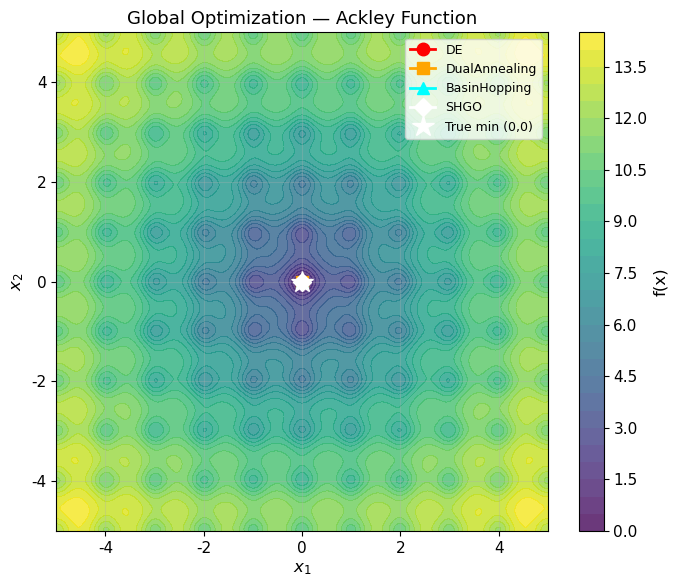

  [Saved] d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Optimization\figs\unit12_global_ackley.png


In [10]:
# ============================================================
# 8. 全域最適化 — 4 種方法比較 (Ackley 函數)
# ============================================================

def ackley(x):
    """二維 Ackley 函數，全局最小值 f(0,0)=0"""
    a, b, c = 20, 0.2, 2*np.pi
    d = len(x)
    return (-a * np.exp(-b * np.sqrt(np.sum(x**2) / d))
            - np.exp(np.sum(np.cos(c * x)) / d)
            + np.e + a)

BOUNDS_GLOBAL = [(-5, 5), (-5, 5)]

import time

methods = {
    'DE':              lambda: differential_evolution(ackley, BOUNDS_GLOBAL, seed=42, tol=1e-8),
    'DualAnnealing':   lambda: dual_annealing(ackley, BOUNDS_GLOBAL, seed=42, maxiter=2000),
    'BasinHopping':    lambda: basinhopping(ackley, x0=[3.0, -3.0], minimizer_kwargs={'method':'L-BFGS-B', 'bounds':BOUNDS_GLOBAL}, niter=200, seed=42),
    'SHGO':            lambda: shgo(ackley, BOUNDS_GLOBAL),
}

print("8. 全域最適化 — Ackley 函數 f*(0,0)=0")
print(f"  {'Method':<16} {'x1*':>8} {'x2*':>8} {'f*':>10} {'nfev':>6} {'時間(s)':>8}")
print(f"  {'-'*60}")

glob_results = {}
for name, solver in methods.items():
    t0 = time.time()
    res = solver()
    elapsed = time.time() - t0
    glob_results[name] = res
    x_sol = res.x
    nfev = getattr(res, 'nfev', '—')
    print(f"  {name:<16} {x_sol[0]:>8.4f} {x_sol[1]:>8.4f} {res.fun:>10.6f} {str(nfev):>6} {elapsed:>8.3f}")

# --- 繪製等高線 + 各方法解 ---
x1g = np.linspace(-5, 5, 300)
x2g = np.linspace(-5, 5, 300)
X1g, X2g = np.meshgrid(x1g, x2g)
Zg = np.array([[ackley(np.array([xi, yi])) for xi in x1g] for yi in x2g])

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(X1g, X2g, Zg, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(cf, ax=ax, label='f(x)')

colors_g = {'DE': 'red', 'DualAnnealing': 'orange', 'BasinHopping': 'cyan', 'SHGO': 'white'}
markers_g = {'DE': 'o', 'DualAnnealing': 's', 'BasinHopping': '^', 'SHGO': 'D'}
for name, res in glob_results.items():
    ax.plot(res.x[0], res.x[1], marker=markers_g[name], markersize=9,
            color=colors_g[name], label=f'{name}', zorder=5)

ax.plot(0, 0, 'w*', markersize=16, label='True min (0,0)', zorder=6)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Global Optimization — Ackley Function')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
fig_path = FIG_DIR / "unit12_global_ackley.png"
fig.savefig(fig_path, dpi=120)
plt.show()
print(f"  [Saved] {fig_path}")

---
### 9. 最適化方法選擇指引

根據問題類型選擇適當的 SciPy 函數：

```
問題描述
├── 單變數？
│   └── minimize_scalar()   [bounded / brent / golden]
└── 多變數？
    ├── 線性目標 + 線性限制？
    │   ├── 連續變數 → linprog()
    │   └── 整數/混合整數 → milp()
    ├── 非線性目標？
    │   ├── 無限制條件 → minimize() [BFGS / L-BFGS-B / Nelder-Mead]
    │   ├── 有限制條件 → minimize() [SLSQP / trust-constr]
    │   └── 多局部最小值（非凸）？
    │       └── 全域法：differential_evolution / dual_annealing / shgo / basinhopping
    └── 黑箱 / 昂貴函數？
        └── differential_evolution（黑箱友好）
```

In [11]:
# ============================================================
# 9. 總結：scipy.optimize 方法一覽比較表
# ============================================================

summary_data = [
    # (函數,           方法/參數,         問題類型,             需要邊界, 整數?)
    ("minimize_scalar","bounded/brent",   "單變數無限制/有界",   "可選",  "否"),
    ("minimize",       "BFGS/L-BFGS-B",  "多變數無限制（光滑）","否",   "否"),
    ("minimize",       "Nelder-Mead",    "多變數無限制（雜訊）","否",   "否"),
    ("minimize",       "SLSQP",          "有限制 NLP",          "可選",  "否"),
    ("minimize",       "trust-constr",   "有限制 NLP（大規模）","可選",  "否"),
    ("linprog",        "highs",          "線性規劃 (LP)",       "是",   "否"),
    ("milp",           "HiGHS",          "混合整數 LP (MILP)",  "是",   "是"),
    ("differential_evolution","DE",      "全域（黑箱/非凸）",   "是",   "否"),
    ("dual_annealing", "SA+局部",        "全域（非凸）",        "是",   "否"),
    ("shgo",           "同倫",           "全域（光滑）",        "是",   "否"),
    ("basinhopping",   "擾動+局部",      "全域（需初始點）",    "可選",  "否"),
]

print("=" * 75)
print(f"  {'函數':<23} {'方法/後端':<16} {'適用問題':<20} {'邊界':>5} {'整數':>5}")
print(f"  {'-'*73}")
for row in summary_data:
    print(f"  {row[0]:<23} {row[1]:<16} {row[2]:<20} {row[3]:>5} {row[4]:>5}")
print("=" * 75)
print()
print("  提示：遇到複雜最適化問題，建議先用局部法確認收斂行為，")
print("        再視需要切換到全域法或使用多起始點策略（multi-start）。")

  函數                      方法/後端            適用問題                    邊界    整數
  -------------------------------------------------------------------------
  minimize_scalar         bounded/brent    單變數無限制/有界               可選     否
  minimize                BFGS/L-BFGS-B    多變數無限制（光滑）               否     否
  minimize                Nelder-Mead      多變數無限制（雜訊）               否     否
  minimize                SLSQP            有限制 NLP                 可選     否
  minimize                trust-constr     有限制 NLP（大規模）            可選     否
  linprog                 highs            線性規劃 (LP)                是     否
  milp                    HiGHS            混合整數 LP (MILP)           是     是
  differential_evolution  DE               全域（黑箱/非凸）                是     否
  dual_annealing          SA+局部            全域（非凸）                   是     否
  shgo                    同倫               全域（光滑）                   是     否
  basinhopping            擾動+局部            全域（需初始點）                可選     否

  提示：遇到複雜最適